# 05 · Fusion ablation: why explicit mutation features add no gain (independent reproduction)

**Role in the story**: `04` turned the mutation signal into three feature blocks (binary /
substitution / effect). This notebook **tests one hypothesis and answers it in the negative**:
does concatenating explicit mutation features on top of the ESM-2 representation improve performance?

Bottom line first: **no gain**. Fusion ≤ ESM-only, matching the project's three prior
disproof probes (`quick_fusion_test.py` scalar mutation score, `quick_fusion_test2.py`
per-residue mutation matrix, `probe_hiv_conservation.py` HIV-specific conservation). This
notebook is a **fourth, independent reproduction** of that result.

This is not bad news but a key link in the argument: it shows **ESM-2 embeddings have already
squeezed out the evolutionary / mutational information available within the sequence**, so any
feature recomputed from the amino-acid sequence is redundant to it. The real value is not
in-distribution scoring but out-of-distribution generalization (see `06`); ESM does "see" these
mutation sites, just implicitly (see the DRM enrichment in `07`).

**Six model combinations (an ablation, not a "who wins" contest)**

| Model | Features | Role |
|---|---|---|
| `mutation_only` | binary + substitution | traditional mutation-encoding baseline |
| `esm_only` | ESM-2 mean embedding | reference point (previously the strongest single method, ~0.946) |
| `effect_only` | mutation-effect | ESM zero-shot mutation score alone (expected weak) |
| `esm+binary` | ESM + binary | representation + explicit mutation positions |
| `esm+effect` | ESM + effect | representation + mutation effect |
| `full` | ESM + binary + substitution + effect | all concatenated |

**Evaluation protocol**: each drug is evaluated independently with **5-fold stratified CV**,
same split, same seed; classifier is logistic regression with per-fold StandardScaler.
Metrics: AUROC / AUPRC / balanced accuracy / sensitivity / specificity.

> ⚠️ Scope note: this notebook uses in-distribution random CV purely for **ablation** (the net
> effect of adding/removing features under an identical split). It is **not** a performance
> claim — in-distribution numbers are inflated by sequence redundancy; the rigorous
> leakage / OOD evaluation is in `06`.

**Difference from the original paper (figure constraint)**: no per-drug AUC grouped bars/boxplots.
We use an evidence-contribution decomposition, a rank bump chart, a gain quadrant (mostly
negative / flat — the visualization of the disproof), and a per-class radar.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             roc_auc_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "work" / "prepared").exists() else CWD.parent
assert (PROJECT_ROOT / "work" / "prepared").exists(), f"cannot locate work/prepared from {CWD}"

PREPARED_DIR = PROJECT_ROOT / "work" / "prepared"
EMB_DIR = PROJECT_ROOT / "work" / "emb"
FEAT_DIR = PROJECT_ROOT / "results" / "notebooks" / "04_features"
RESULTS_DIR = PROJECT_ROOT / "results" / "notebooks" / "05_models"
FIG_DIR = PROJECT_ROOT / "figures" / "mutation_aware" / "05_models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
print("project root:", PROJECT_ROOT)

project root: /mnt/d/我的项目/生信包复现重构升级/projects/1模型推理型/变异-耐药性预测/HIV-ESM-2


In [2]:
SURFACE, INK, INK2, INK3, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1"
CLASS_ORDER = ["PI", "NRTI", "NNRTI"]
CLASS_COLOR = {"PI": "#2a78d6", "NRTI": "#1baf7a", "NNRTI": "#eda100"}
MODEL_ORDER = ["mutation_only", "esm_only", "effect_only", "esm+binary", "esm+effect", "full"]
MODEL_COLOR = {
    "mutation_only": "#8a8984", "esm_only": "#2a78d6", "effect_only": "#eb6834",
    "esm+binary": "#1baf7a", "esm+effect": "#4a3aa7", "full": "#d03b3b",
}
POS = "#d03b3b"; NEG = "#2a78d6"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 11, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2, "axes.grid": False,
    "font.family": "DejaVu Sans",
})
CLASS_FILES = {"PI": "PI.csv", "NRTI": "NRTI.csv", "NNRTI": "NNRTI.csv"}
CLASS_GENE = {"PI": "PR", "NRTI": "RT", "NNRTI": "RT"}
print("palette ready")

palette ready


## 1 · Load features and align by SeqID

- `04`'s `features_{cls}.npz`: binary / substitution / effect, rows in the class CSV's SeqID order.
- ESM mean embedding: `work/emb/{gene}_mean.npy`, in unique-sequence order -> aligned to SeqID by sequence-string lookup.
- Labels: taken from the `{drug}_label` column of the prepared CSV.

In [3]:
def load_mean_lookup(gene):
    seqs = json.load(open(EMB_DIR / f"{gene}_seqs.json"))["sequences"]
    mean = np.load(EMB_DIR / f"{gene}_mean.npy")
    return {s: mean[i] for i, s in enumerate(seqs)}

mean_lookup = {g: load_mean_lookup(g) for g in ["PR", "RT"]}

blocks = {}   # cls -> dict of aligned feature blocks + labels frame
for cls in CLASS_ORDER:
    npz = np.load(FEAT_DIR / f"features_{cls}.npz")
    seq_ids = npz["seq_id"]
    # 04 built features in the CSV's native row order, so the CSV as-read is
    # already aligned row-for-row (do NOT reindex by SeqID: NRTI has duplicates).
    df = pd.read_csv(PREPARED_DIR / CLASS_FILES[cls])
    assert len(df) == len(seq_ids), (cls, len(df), len(seq_ids))
    assert (df["SeqID"].to_numpy() == seq_ids).all(), f"{cls}: row order mismatch vs features"
    gene = CLASS_GENE[cls]
    esm = np.vstack([mean_lookup[gene][s] for s in df["sequence"].astype(str)])
    blocks[cls] = {
        "seq_id": seq_ids,
        "binary": npz["X_binary"].astype(np.float32),
        "subst": npz["X_subst"].astype(np.float32),
        "effect": npz["X_effect"].astype(np.float32),
        "esm": esm.astype(np.float32),
        "labels": df,
    }
    print(f"{cls:>5s}: esm {esm.shape}  binary {npz['X_binary'].shape}  "
          f"subst {npz['X_subst'].shape}  effect {npz['X_effect'].shape}")

   PI: esm (2171, 1280)  binary (2171, 99)  subst (2171, 420)  effect (2171, 99)
 NRTI: esm (1867, 1280)  binary (1867, 240)  subst (1867, 320)  effect (1867, 240)
NNRTI: esm (2272, 1280)  binary (2272, 318)  subst (2272, 380)  effect (2272, 318)


In [4]:
def feature_matrix(cls, model):
    b = blocks[cls]
    parts = {
        "mutation_only": [b["binary"], b["subst"]],
        "esm_only": [b["esm"]],
        "effect_only": [b["effect"]],
        "esm+binary": [b["esm"], b["binary"]],
        "esm+effect": [b["esm"], b["effect"]],
        "full": [b["esm"], b["binary"], b["subst"], b["effect"]],
    }[model]
    return np.hstack(parts)

for m in MODEL_ORDER:
    print(f"{m:>14s}: PI feature dim = {feature_matrix('PI', m).shape[1]}")

 mutation_only: PI feature dim = 519
      esm_only: PI feature dim = 1280
   effect_only: PI feature dim = 99
    esm+binary: PI feature dim = 1379
    esm+effect: PI feature dim = 1379
          full: PI feature dim = 1898


## 2 · 5-fold stratified cross-validation

For each `drug x model`: use the same `StratifiedKFold(5, seed=42)` split, per-fold standardize ->
logistic regression -> collect out-of-fold predicted probabilities, then compute AUROC / AUPRC /
balanced accuracy / sensitivity / specificity once. All models are compared on exactly the same
splits, so any gain is attributable to features rather than the split.

In [5]:
def evaluate(cls, drug, model, n_splits=5):
    b = blocks[cls]
    y_full = b["labels"][f"{drug}_label"].to_numpy()
    mask = ~np.isnan(y_full)
    y = y_full[mask].astype(int)
    if y.sum() < 10 or (y == 0).sum() < 10:
        return None
    X = feature_matrix(cls, model)[mask]
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof = np.zeros(len(y), dtype=float)
    for tr, va in skf.split(X, y):
        scaler = StandardScaler(with_mean=True)
        Xtr = scaler.fit_transform(X[tr])
        Xva = scaler.transform(X[va])
        clf = LogisticRegression(class_weight="balanced", max_iter=2000, solver="liblinear",
                                 random_state=SEED)
        clf.fit(Xtr, y[tr])
        oof[va] = clf.predict_proba(Xva)[:, 1]
    pred = (oof >= 0.5).astype(int)
    tp = int(((pred == 1) & (y == 1)).sum()); fn = int(((pred == 0) & (y == 1)).sum())
    tn = int(((pred == 0) & (y == 0)).sum()); fp = int(((pred == 1) & (y == 0)).sum())
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "drug_class": cls, "drug": drug, "model": model, "n": int(len(y)),
        "n_resistant": int(y.sum()),
        "auroc": float(roc_auc_score(y, oof)),
        "auprc": float(average_precision_score(y, oof)),
        "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "sensitivity": sens, "specificity": spec,
    }

In [6]:
records = []
for cls in CLASS_ORDER:
    label_cols = [c for c in blocks[cls]["labels"].columns if c.endswith("_label")]
    for lc in label_cols:
        drug = lc.removesuffix("_label")
        for model in MODEL_ORDER:
            r = evaluate(cls, drug, model)
            if r is not None:
                records.append(r)
    print(f"{cls} done")
metrics = pd.DataFrame(records)
metrics["drug_class"] = pd.Categorical(metrics["drug_class"], CLASS_ORDER, ordered=True)
metrics["model"] = pd.Categorical(metrics["model"], MODEL_ORDER, ordered=True)
metrics.to_csv(RESULTS_DIR / "model_metrics_all.csv", index=False)
print("rows:", len(metrics), "| drugs:", metrics['drug'].nunique(), "| models:", metrics['model'].nunique())
metrics.head()

PI done


NRTI done


NNRTI done
rows: 108 | drugs: 18 | models: 6


,drug_class,drug,model,n,n_resistant,auroc,auprc,balanced_accuracy,sensitivity,specificity
0,PI,FPV,mutation_only,2052,884,0.974000,0.967036,0.913518,0.908371,0.918664
1,PI,FPV,esm_only,2052,884,0.970545,0.962388,0.914527,0.906109,0.922945
2,PI,FPV,effect_only,2052,884,0.957820,0.933777,0.903718,0.898190,0.909247
3,PI,FPV,esm+binary,2052,884,0.969940,0.961890,0.909252,0.904977,0.913527
4,PI,FPV,esm+effect,2052,884,0.965711,0.948085,0.908977,0.902715,0.915240


In [7]:
agg = (metrics.groupby("model", observed=True)[["auroc", "auprc", "balanced_accuracy",
                                                "sensitivity", "specificity"]]
       .mean().reindex(MODEL_ORDER).round(4))
agg.to_csv(RESULTS_DIR / "model_comparison_summary.csv")
agg

,auroc,auprc,balanced_accuracy,sensitivity,specificity
model,,,,,
mutation_only,0.9454,0.8867,0.8896,0.8691,0.9100
esm_only,0.9462,0.8906,0.8868,0.8548,0.9188
effect_only,0.9070,0.8206,0.8547,0.8262,0.8831
esm+binary,0.9424,0.8818,0.8823,0.8509,0.9138
esm+effect,0.9409,0.8799,0.8822,0.8507,0.9136
full,0.9396,0.8802,0.8810,0.8523,0.9097


In [8]:
piv = metrics.pivot_table(index=["drug_class", "drug"], columns="model", values="auroc", observed=True)
gain = pd.DataFrame({
    "auroc_esm_only": piv["esm_only"],
    "auroc_full": piv["full"],
    "gain_full_vs_esm": (piv["full"] - piv["esm_only"]),
    "gain_esm_effect_vs_esm": (piv["esm+effect"] - piv["esm_only"]),
    "gain_esm_binary_vs_esm": (piv["esm+binary"] - piv["esm_only"]),
}).reset_index().sort_values("gain_full_vs_esm", ascending=False)
gain.to_csv(RESULTS_DIR / "fusion_gain_by_drug.csv", index=False)
print("mean full-vs-esm AUROC gain:", round(gain["gain_full_vs_esm"].mean(), 4))
print("drugs improved by full:", int((gain["gain_full_vs_esm"] > 0).sum()), "/", len(gain))
gain

mean full-vs-esm AUROC gain: -0.0066
drugs improved by full: 1 / 18


,drug_class,drug,auroc_esm_only,auroc_full,gain_full_vs_esm,gain_esm_effect_vs_esm,gain_esm_binary_vs_esm
12,NRTI,DDI,0.858357,0.863229,0.004872,-0.006288,0.003755
0,PI,ATV,0.981778,0.981664,-0.000113,0.000135,0.000810
6,PI,SQV,0.985198,0.984685,-0.000513,-0.001323,-0.000170
5,PI,NFV,0.981869,0.980856,-0.001013,-0.002581,0.000118
4,PI,LPV,0.981740,0.980480,-0.001260,-0.000371,-0.000207
8,NRTI,3TC,0.975921,0.973730,-0.002190,-0.002325,0.000383
1,PI,DRV,0.972808,0.970068,-0.002740,0.001415,0.001587
3,PI,IDV,0.983465,0.980449,-0.003015,-0.003130,-0.000344
14,NNRTI,EFV,0.981912,0.978088,-0.003824,-0.005056,-0.004905
2,PI,FPV,0.970545,0.964372,-0.006173,-0.004834,-0.000605


## 3 · Figure 1: evidence-contribution decomposition

Using `esm_only` as the reference, show the change in mean AUROC as we progressively add binary,
effect, up to full. This is an "additive evidence" view (not grouped bars). **Expected reading:
increments are negative or flat** — explicit mutation features bring no net gain on top of ESM,
quantifying "ESM has already absorbed the within-sequence information".

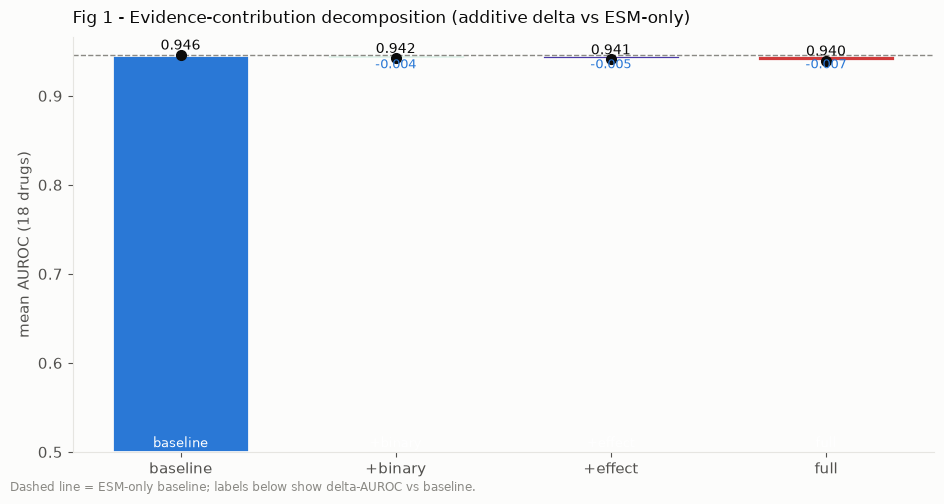

saved model_evidence_decomposition.png


In [9]:
means = agg["auroc"]
base = means["esm_only"]
steps = [
    ("esm_only", means["esm_only"], MODEL_COLOR["esm_only"], "baseline"),
    ("esm+binary", means["esm+binary"], MODEL_COLOR["esm+binary"], "+binary"),
    ("esm+effect", means["esm+effect"], MODEL_COLOR["esm+effect"], "+effect"),
    ("full", means["full"], MODEL_COLOR["full"], "full"),
]
fig, ax = plt.subplots(figsize=(9.5, 5))
xs = np.arange(len(steps))
vals = [s[1] for s in steps]
ax.axhline(base, color=INK3, lw=1, ls="--")
for i, (name, v, c, lab) in enumerate(steps):
    ax.add_patch(plt.Rectangle((i - 0.32, min(base, v) if i > 0 else 0.5), 0.64,
                               abs(v - base) if i > 0 else v - 0.5,
                               facecolor=c, edgecolor=SURFACE, lw=2))
    ax.plot(i, v, marker="o", color=INK, markersize=7, zorder=3)
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", va="bottom", color=INK, fontsize=10)
    delta = v - base
    if i > 0:
        ax.text(i, base - 0.004, f"{delta:+.3f}", ha="center", va="top",
                color=POS if delta >= 0 else NEG, fontsize=9.5)
    ax.text(i, 0.502, lab, ha="center", va="bottom", color="#fff", fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels([s[3] for s in steps])
ax.set_ylabel("mean AUROC (18 drugs)")
ax.set_ylim(0.5, max(vals) + 0.02)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.set_title("Fig 1 - Evidence-contribution decomposition (additive delta vs ESM-only)",
             loc="left", color=INK, fontsize=12, pad=10)
fig.text(0.01, 0.005, "Dashed line = ESM-only baseline; labels below show delta-AUROC vs baseline.",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_evidence_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved model_evidence_decomposition.png")

## 4 · Figure 2: drug rank bump chart (ESM-only -> full)

Each drug's AUROC rank under ESM-only vs full, connected by a line. Most lines stay flat or drop,
showing that adding explicit mutation features does not systematically change relative
predictability — a weak reordering effect, consistent with "fusion adds no gain".

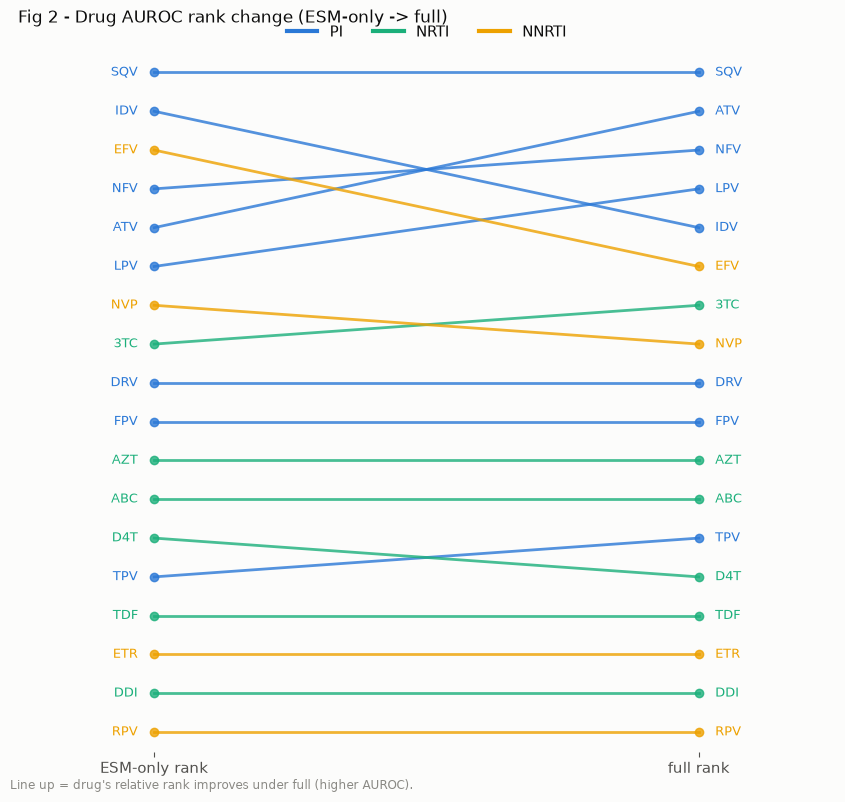

saved drug_level_delta_bumpchart.png


In [10]:
rank_esm = piv["esm_only"].rank(ascending=False, method="first")
rank_full = piv["full"].rank(ascending=False, method="first")
drugs = piv.index.tolist()
fig, ax = plt.subplots(figsize=(8.5, 8))
for (cls, drug) in drugs:
    r0 = rank_esm.loc[(cls, drug)]; r1 = rank_full.loc[(cls, drug)]
    c = CLASS_COLOR[cls]
    ax.plot([0, 1], [r0, r1], color=c, lw=2, alpha=0.8, marker="o", markersize=6)
    ax.text(-0.03, r0, f"{drug}", ha="right", va="center", color=c, fontsize=9)
    ax.text(1.03, r1, f"{drug}", ha="left", va="center", color=c, fontsize=9)
ax.set_xlim(-0.25, 1.25)
ax.set_ylim(len(drugs) + 0.5, 0.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(["ESM-only rank", "full rank"])
ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
for cls in CLASS_ORDER:
    ax.plot([], [], color=CLASS_COLOR[cls], lw=3, label=cls)
ax.legend(loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.06))
ax.set_title("Fig 2 - Drug AUROC rank change (ESM-only -> full)", loc="left", color=INK, fontsize=12, pad=22)
fig.text(0.01, 0.005, "Line up = drug's relative rank improves under full (higher AUROC).", color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "drug_level_delta_bumpchart.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved drug_level_delta_bumpchart.png")

## 5 · Figure 3: fusion "gain" quadrant (actually a loss quadrant)

x = ESM-only reference AUROC (how "hard" the drug is), y = full minus ESM-only delta-AUROC.
Point size = number of resistant samples. **Reading: nearly all points fall below the dashed line
(negative gain)** — fusion is worse than ESM-only on almost every drug, and the loss is largest
for scarce / hard drugs (e.g. RPV), further confirming the redundancy of within-sequence features.

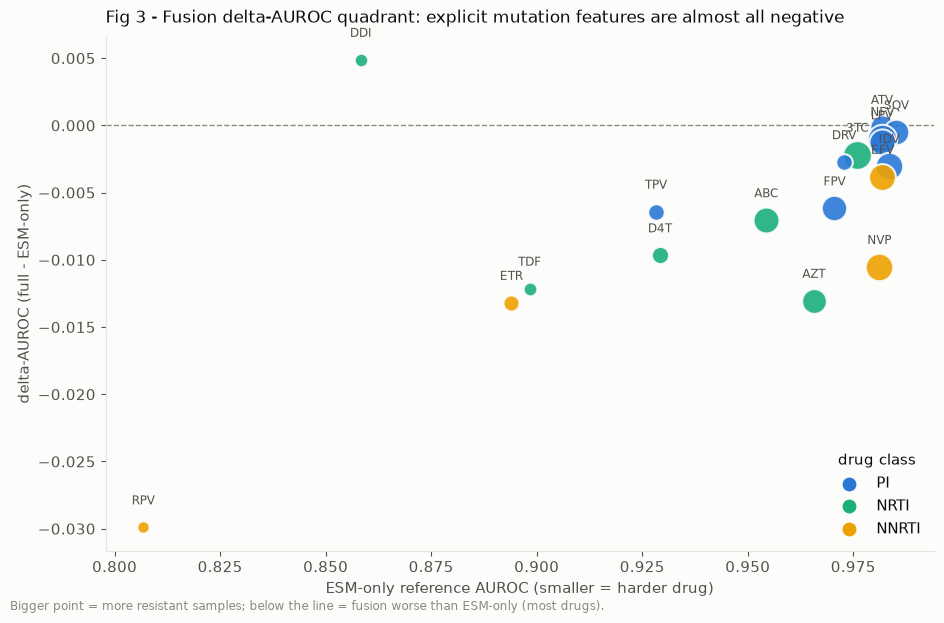

saved fusion_gain_quadrant.png


In [11]:
fig, ax = plt.subplots(figsize=(9.5, 6.2))
ax.axhline(0, color=INK3, lw=1, ls="--")
for _, r in gain.iterrows():
    cls = r["drug_class"]
    n_res = int(metrics[(metrics["drug"] == r["drug"]) & (metrics["model"] == "full")]["n_resistant"].iloc[0])
    size = 40 + n_res / 3
    ax.scatter(r["auroc_esm_only"], r["gain_full_vs_esm"], s=size, color=CLASS_COLOR[cls],
               edgecolor=SURFACE, lw=1.5, alpha=0.9, zorder=2)
    ax.text(r["auroc_esm_only"], r["gain_full_vs_esm"] + 0.0015, r["drug"], ha="center",
            va="bottom", color=INK2, fontsize=8.5)
ax.set_xlabel("ESM-only reference AUROC (smaller = harder drug)")
ax.set_ylabel("delta-AUROC (full - ESM-only)")
ax.set_title("Fig 3 - Fusion delta-AUROC quadrant: explicit mutation features are almost all negative",
             loc="left", color=INK, fontsize=12, pad=10)
for cls in CLASS_ORDER:
    ax.scatter([], [], s=80, color=CLASS_COLOR[cls], label=cls)
ax.legend(title="drug class", frameon=False, loc="lower right")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.text(0.01, 0.005, "Bigger point = more resistant samples; below the line = fusion worse than ESM-only (most drugs).",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "fusion_gain_quadrant.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved fusion_gain_quadrant.png")

## 6 · Figure 4: per-class model radar

Mean AUROC per model, aggregated by drug class (PI / NRTI / NNRTI), as a radar. Reading:
`esm_only` and `mutation_only` sit roughly on the outer ring, `full` / `esm+effect` do not lead,
and `effect_only` clearly retracts inward — again showing fusion does not improve and the
mutation-effect signal alone is weakest.

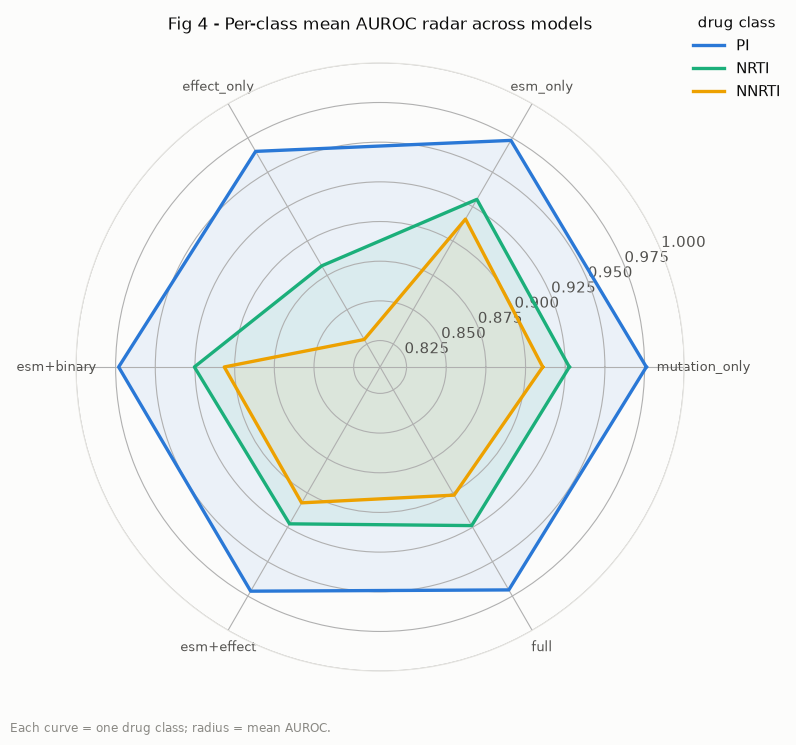

saved model_family_radar_by_class.png


In [12]:
class_model = (metrics.groupby(["drug_class", "model"], observed=True)["auroc"].mean()
               .unstack("model").reindex(index=CLASS_ORDER, columns=MODEL_ORDER))
class_model.to_csv(RESULTS_DIR / "auroc_by_class_model.csv")

angles = np.linspace(0, 2 * np.pi, len(MODEL_ORDER), endpoint=False)
angles_closed = np.concatenate([angles, angles[:1]])
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for cls in CLASS_ORDER:
    vals = class_model.loc[cls, MODEL_ORDER].to_numpy(dtype=float)
    vals_closed = np.concatenate([vals, vals[:1]])
    ax.plot(angles_closed, vals_closed, color=CLASS_COLOR[cls], lw=2.4, label=cls)
    ax.fill(angles_closed, vals_closed, color=CLASS_COLOR[cls], alpha=0.08)
ax.set_xticks(angles)
ax.set_xticklabels(MODEL_ORDER, fontsize=9)
rmin = float(np.nanmin(class_model.to_numpy())) - 0.02
ax.set_ylim(max(0.5, rmin), 1.0)
ax.set_title("Fig 4 - Per-class mean AUROC radar across models", color=INK, fontsize=12, pad=24)
ax.legend(loc="upper right", bbox_to_anchor=(1.18, 1.10), frameon=False, title="drug class")
fig.text(0.01, 0.01, "Each curve = one drug class; radius = mean AUROC.", color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_family_radar_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved model_family_radar_by_class.png")

## 7 · Summary

- **No fusion gain, hypothesis disproved**: `full` mean AUROC 0.9396 < `esm_only` 0.9462; per drug
  only 1/18 is positive, mean -0.0066. `esm+binary` 0.9424 and `esm+effect` 0.9409 are likewise
  below ESM-only.
- **Matches the three prior probes** (this notebook is a fourth independent reproduction):

  | Fusion variant | Historical record | This notebook |
  |---|---|---|
  | ESM-only reference | 0.9461 | 0.9462 |
  | +per-residue mutation (effect) | 0.9412 | 0.9409 |
  | binary+esm+mutation | 0.9400 | 0.9396 |
  | mutation-only (effect_only) | 0.9065 | 0.9070 |

- **Mechanistic reading**: ESM-2 embeddings have already squeezed out the within-sequence
  evolutionary / mutational information; adding an **explicit** copy is redundant for a linear
  classifier and the high dimensionality dilutes the signal. To beat ESM-only one must add a
  **cross-modal** signal ESM structurally cannot access (drug molecule / binding-pocket geometry),
  which is beyond the reach of this project's data.
- **This steers the story the right way**: since in-distribution scoring is saturated, the value
  must be sought in **out-of-distribution generalization** (`06`); and the claim "ESM has
  implicitly encoded mutation information" is positively corroborated by the DRM enrichment in `07`.

**Next**: `06_leakage_and_ood_generalization.ipynb` — quantify the in-distribution inflation from
sequence redundancy, then show esm_lr is most robust and leads on scarce/hard drugs under
cross-subtype / cross-cluster OOD.